3D TV-Regularized Sparse-View CT Reconstruction (APGM Solver, Sharded)
======================================================================

This example demonstrates solution of a sparse-view, 3D CT
reconstruction problem with isotropic total variation (TV)
regularization and a box constraint

  $$\mathrm{argmin}_{\mathbf{x}} \; (1/2) \| \mathbf{y} - C \mathbf{x}
  \|_2^2 + \lambda \| D \mathbf{x} \|_{2,1} + \iota_{[0,1]}(\mathbf{x})
  \;,$$

where $C$ is the X-ray transform (the CT forward projection operator),
$\mathbf{y}$ is the sinogram, $D$ is a 3D finite difference operator,
$\iota_{[0,1]}(\cdot)$ is the indicator function of the box constraint
on the the range $[0,1]$, and $\mathbf{x}$ is the reconstructed image.

The problem is solved using an approximation of the proximal operator of
the TV norm and the proximal average to combine it with the proximal
operator of the box constraint. Array sharding is used to allow spreading
the memory footprint and computation across multiple GPUs

In [1]:
import numpy as np

import jax
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P

import komplot as kplt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scico.numpy as snp
from scico import functional, linop, loss, metric
from scico.data import foam_phantom
from scico.linop.xray.astra import XRayTransform3D, angle_to_vector
from scico.numpy.util import pad_to_divisible
from scico.optimize import AcceleratedPGM
from scico.util import device_info
kplt.config_notebook_plotting()

try:
    import jax_smi

    have_jax_smi = True
except ImportError:
    have_jax_smi = False

Create a ground truth image and projector.

In [2]:
vol = foam_phantom()
Nz, Ny, Nx = vol.shape

n_projection = 64  # number of projections
angles = np.linspace(0, np.pi, n_projection, endpoint=False)  # evenly spaced projection angles
det_spacing = [1.0, 1.0]
det_count = [Nz, max(Nx, Ny)]
vectors = angle_to_vector(det_spacing, angles)

Create mesh and sharding.

In [3]:
num_dev = jax.device_count()
mesh = jax.make_mesh(
    (num_dev,),
    ("a",),
    axis_types=(AxisType.Auto,),
)
xshard = NamedSharding(mesh, P("a"))


# If jax_smi module installed, initialize it to allow memory usage tracking
# using jax-smi.
if have_jax_smi:
    jax_smi.initialise_tracking()

Pad volume to allow for sharding.

In [4]:
vol_pad, vol_slice = pad_to_divisible(vol, axes=(0,), divisors=(num_dev,))


# It would have been more straightforward to use the det_spacing and angles keywords
# in this case (since vectors is just computed directly from these two quantities), but
# the more general form is used here as a demonstration.
C = XRayTransform3D(
    vol_pad.shape,
    det_count=det_count,
    vectors=vectors,
    input_sharding=xshard,
    output_sharding=xshard,
)  # CT projection operator
y = C @ vol_pad  # sinogram

Set up problem and solver. We want to minimize the functional

  $$\mathrm{argmin}_{\mathbf{x}} \; (1/2) \| \mathbf{y} - C \mathbf{x}
  \|_2^2 + \lambda \| D \mathbf{x} \|_{2,1} + \iota_{[0,1]}(\mathbf{x})
  \;,$$

where $C$ is the X-ray transform $D$ is a finite difference
operator, and $\iota_{[0,1]}(\cdot)$ is the indicator function of the box
constraint on the the range $[0,1]$.

In [5]:
λ = 4e0  # TV norm regularization parameter
L0 = linop.operator_norm(C, maxiter=10, device=xshard) ** 2
maxiter = 250  # number of APGM iterations

f = loss.SquaredL2Loss(y=y, A=C)
g0 = λ * functional.IsotropicTVNorm(circular=True, input_shape=vol.shape)
g1 = functional.BoxIndicator(lb=0.0, ub=1.0)
g = functional.ProximalAverage((g0, g1), (0.5, 0.5))
x0 = snp.zeros(C.input_shape, dtype=np.float32, device=xshard)
solver = AcceleratedPGM(
    f=f, g=g, L0=L0, x0=x0, maxiter=maxiter, itstat_options={"display": True, "period": 50}
)

Run the solver.

In [6]:
print(f"Solving on {device_info(xshard)}\n")
vol_recon = solver.solve()[vol_slice]

print(
    "TV Restruction\nSNR: %.2f (dB), MAE: %.3f"
    % (metric.snr(vol, vol_recon), metric.mae(vol, vol_recon))
)

Solving on 
GPU  0  NVIDIA A100-SXM4-80GB
GPU  1  NVIDIA A100-SXM4-80GB
GPU  2  NVIDIA A100-SXM4-80GB
GPU  3  NVIDIA A100-SXM4-80GB
GPU  4  NVIDIA A100-SXM4-80GB
GPU  5  NVIDIA A100-SXM4-80GB
GPU  6  NVIDIA A100-SXM4-80GB
GPU  7  NVIDIA A100-SXM4-80GB



Iter  Time      Objective  L          Residual 
-----------------------------------------------
   0  6.98e+00  5.476e+09  3.135e+04  2.018e+03


  50  2.42e+02  4.517e+07  3.135e+04  3.447e+00


 100  4.74e+02  2.832e+07  3.135e+04  8.735e-01


 150  7.03e+02  2.629e+07  3.135e+04  3.924e-01


 200  9.32e+02  2.591e+07  3.135e+04  1.859e-01


 249  1.15e+03  2.585e+07  3.135e+04  1.008e-01


TV Restruction
SNR: 18.25 (dB), MAE: 0.012


Show the recovered image.

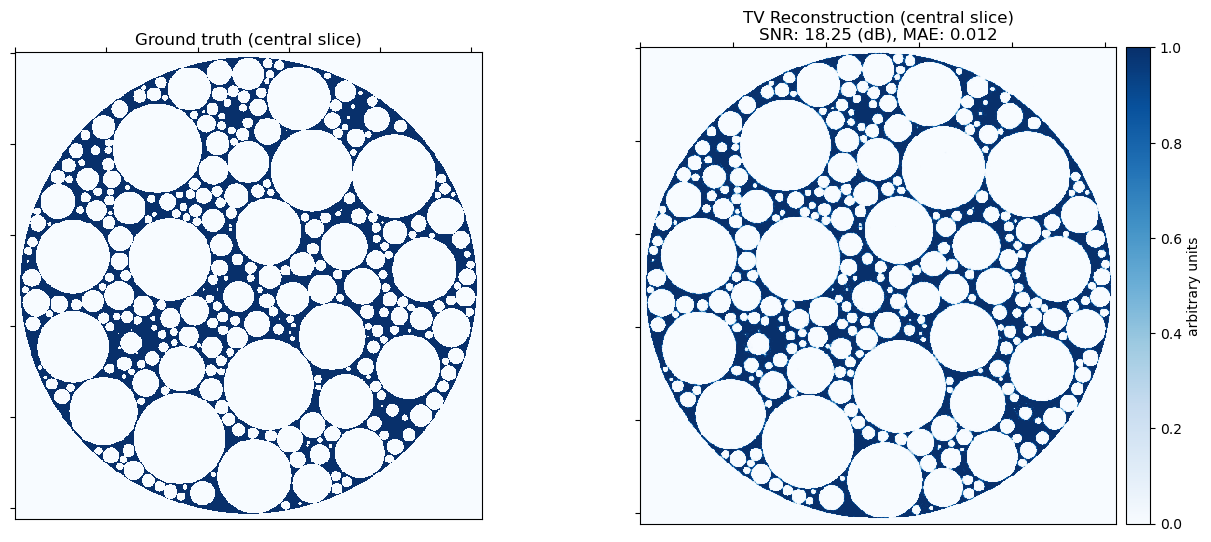

In [7]:
fig, ax = kplt.subplots(nrows=1, ncols=2, layout="constrained", figsize=(12.5, 6))
kplt.imview(
    vol[32],
    title="Ground truth (central slice)",
    cmap=kplt.cm.Blues,
    show_cbar=None,
    ax=ax[0],
)
kplt.imview(
    vol_recon[32],
    title="TV Reconstruction (central slice)\nSNR: %.2f (dB), MAE: %.3f"
    % (metric.snr(vol, vol_recon), metric.mae(vol, vol_recon)),
    cmap=kplt.cm.Blues,
    ax=ax[1],
)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(ax[1].get_images()[0], cax=cax, label="arbitrary units")
fig.get_layout_engine().set(w_pad=0.55, h_pad=0.05)
fig.show()